# V4 — Process-Evaluation Metrics

Pointwise scores compare *amplitudes* — a model that smooths fields can keep RMSE small while quietly violating the underlying physics. V4 metrics test physical consistency directly: geostrophic balance, mass conservation, density stratification, heat budget closure. The numbers are properties of a single dataset, not a pred-vs-ref comparison, so each candidate model is scored on its own.

This notebook exercises V4 on a real Gulf Stream slice with **three datasets**:

- **GLORYS12** (`glorys12_3d_gulfstream_2023-06.nc`) — 5 days, 22 depths, 1/12° — treated as the *truth*. Carries `zos`, `uo`, `vo`, `thetao`, `so`.
- **DUACS L4** (`duacs_gulfstream_2023-06.nc`) — same window, 1/8°, SSH only (`adt`). The *real* observational "model".
- **Smoothed twin** — synthetic baseline, gaussian-smoothed GLORYS. Same fields as GLORYS but spatially blurred.

Different metrics see different subsets of the three because each metric needs different inputs:

| Metric | GLORYS | DUACS | Smoothed |
|---|---|---|---|
| `RMSE` on SSH | 0 (sanity) | ✓ | ✓ |
| `GeostrophicBalanceError` | ✓ | ✓ (derive `u`, `v` from SSH) | ✓ |
| `DivergenceError` | ✓ | — (no `uo`/`vo`) | ✓ |
| `DensityInversionFraction` | ✓ | — | ✓ |
| `HeatBudgetResidual` | ✓ | — | ✓ |

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.ndimage import gaussian_filter

from xrtoolz import Graph, Input, Sequential, Signature
from xrtoolz.budgets import HeatBudgetResidual
from xrtoolz.calc import grid_metrics_from_coords
from xrtoolz.geo.operators import RemoveMean, RenameVariables, ValidateCoords
from xrtoolz.metrics import (
    RMSE,
    DensityInversionFraction,
    DivergenceError,
    GeostrophicBalanceError,
)
from xrtoolz.ocn import geostrophic_velocities

## 1 — Load the three datasets

Both cached netCDFs cover 2023-06-01 → 2023-06-05 over `[-70, -50] × [30, 45]`. Section 11 has the `copernicusmarine` snippets for rebuilding the cache.

In [2]:
from pathlib import Path

GLORYS_CACHE = Path("../../.cache/glorys12_3d_gulfstream_2023-06.nc")
DUACS_CACHE = Path("../../.cache/duacs_gulfstream_2023-06.nc")

glorys = xr.open_dataset(GLORYS_CACHE).rename(
    {"latitude": "lat", "longitude": "lon"}
)
# GLORYS has tiny float-precision wobble in lat/lon; resnap to a uniform grid
# so the geometric primitives accept the coords as uniformly spaced.
glorys = glorys.assign_coords(
    lat=("lat", np.linspace(float(glorys.lat[0]), float(glorys.lat[-1]), glorys.sizes["lat"])),
    lon=("lon", np.linspace(float(glorys.lon[0]), float(glorys.lon[-1]), glorys.sizes["lon"])),
)

duacs = (
    xr.open_dataset(DUACS_CACHE)
    .isel(time=slice(0, 5))
    .rename({"latitude": "lat", "longitude": "lon"})
    .interp(lat=glorys.lat, lon=glorys.lon)
)

print("GLORYS:", dict(glorys.sizes), list(glorys.data_vars))
print("DUACS:", dict(duacs.sizes), list(duacs.data_vars))

GLORYS: {'time': 5, 'depth': 22, 'lat': 181, 'lon': 241} ['uo', 'vo', 'thetao', 'so', 'zos']
DUACS: {'time': 5, 'lat': 181, 'lon': 241} ['adt']


### Build the smoothed twin

A 2-D gaussian filter (σ = 2 grid cells ≈ 18 km) is applied per (time, depth) slice. NaN-aware: land mask is preserved, fill-with-mean during the filter then re-mask. The twin retains GLORYS's structure but drops sub-mesoscale gradients — the kind of quiet damage RMSE alone can miss.

In [3]:
def smooth_field(da: xr.DataArray, sigma: float = 2.0) -> xr.DataArray:
    """Apply a 2-D gaussian filter slice-by-slice in (lat, lon)."""
    arr = da.values.astype(float)
    out = np.empty_like(arr)
    nan_mask = np.isnan(arr)

    has_time = "time" in da.dims
    has_depth = "depth" in da.dims
    nt = da.sizes["time"] if has_time else 1
    nz = da.sizes["depth"] if has_depth else 1

    for t in range(nt):
        for k in range(nz):
            slc: list = [slice(None)] * da.ndim
            if has_time:
                slc[da.get_axis_num("time")] = t
            if has_depth:
                slc[da.get_axis_num("depth")] = k
            block = arr[tuple(slc)]
            fill = np.nanmean(block) if np.any(~np.isnan(block)) else 0.0
            out[tuple(slc)] = gaussian_filter(np.where(np.isnan(block), fill, block), sigma=sigma)

    out[nan_mask] = np.nan
    return xr.DataArray(out, dims=da.dims, coords=da.coords, attrs=da.attrs)


smoothed = glorys.copy()
for var in ["zos", "uo", "vo", "thetao", "so"]:
    smoothed[var] = smooth_field(glorys[var])

### Snapshot at the surface, day 0

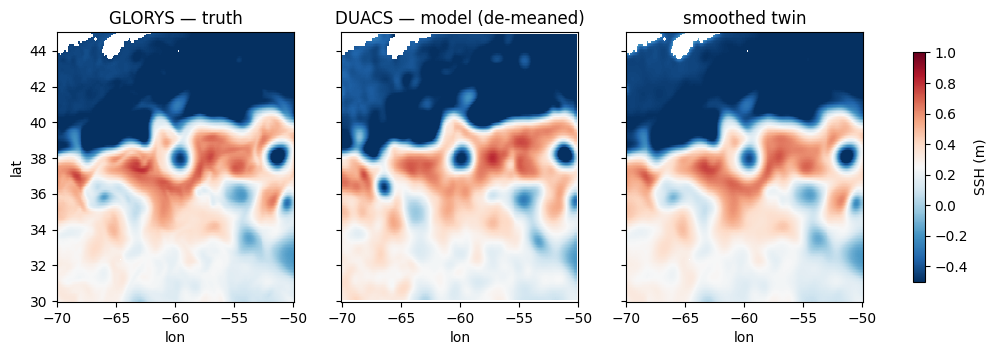

In [4]:
t_idx = 0
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
panels = [
    (glorys["zos"].isel(time=t_idx), "GLORYS — truth"),
    (duacs["adt"].isel(time=t_idx) - float(duacs["adt"].mean()), "DUACS — model (de-meaned)"),
    (smoothed["zos"].isel(time=t_idx), "smoothed twin"),
]
for ax, (da, title) in zip(axes, panels, strict=True):
    im = ax.pcolormesh(da["lon"], da["lat"], da.values, vmin=-0.5, vmax=1.0, cmap="RdBu_r")
    ax.set_title(title)
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
fig.colorbar(im, ax=axes, shrink=0.85, label="SSH (m)")
plt.show()

## 2 — Pointwise SSH skill (the V1 lens)

RMSE on SSH against GLORYS, after removing each field's basin-mean to put DUACS and GLORYS on the same reference. Both candidates look acceptable; smoothing barely registers.

In [5]:
def demean(da: xr.DataArray) -> xr.DataArray:
    return da - da.mean(dim=("lat", "lon"))


ssh_truth = demean(glorys["zos"])
ssh_models = {
    "DUACS": demean(duacs["adt"].rename("zos")),
    "smoothed": demean(smoothed["zos"]),
}

rmse_op = RMSE("zos", dims=("lat", "lon"))
rmse_rows = {
    name: float(
        rmse_op(
            xr.Dataset({"zos": pred}),
            xr.Dataset({"zos": ssh_truth}),
        ).mean(dim="time").values
    )
    for name, pred in ssh_models.items()
}
ssh_table = pd.Series(rmse_rows, name="SSH RMSE vs GLORYS (m)").to_frame()
ssh_table

,SSH RMSE vs GLORYS (m)
DUACS,0.110717
smoothed,0.017706


## 3 — `GeostrophicBalanceError`

How well does each dataset's velocity match the geostrophic balance implied by its SSH? The metric returns a single residual norm per (time) snapshot; we average over time.

- **GLORYS** carries its own `uo`/`vo` so we score it directly.
- **DUACS** has no velocities; we *derive* geostrophic `u`/`v` from `adt` via `xrtoolz.ocn.geostrophic_velocities` and score the resulting Dataset (this is a self-consistency check by construction, but useful as a sanity floor).
- **Smoothed twin** uses its own (smoothed) `uo`/`vo`.

In [6]:
gbe_op = GeostrophicBalanceError(ssh_var="ssh", u_var="u", v_var="v")

g_top = glorys.isel(depth=0).rename({"zos": "ssh", "uo": "u", "vo": "v"})
sm_top = smoothed.isel(depth=0).rename({"zos": "ssh", "uo": "u", "vo": "v"})

duacs_geo = geostrophic_velocities(duacs.rename({"adt": "ssh"}), variable="ssh")
duacs_with_uv = duacs.rename({"adt": "ssh"}).merge(duacs_geo)


def gbe_rms(ds: xr.Dataset) -> float:
    """RMS magnitude of the geostrophic-balance residual."""
    res = gbe_op(ds)
    mag2 = res["r_u"] ** 2 + res["r_v"] ** 2
    return float(np.sqrt(mag2.mean(skipna=True)).values)


gbe_rows = {
    "GLORYS": gbe_rms(g_top),
    "DUACS (geostrophic by construction)": gbe_rms(duacs_with_uv),
    "smoothed": gbe_rms(sm_top),
}
gbe_table = pd.Series(gbe_rows, name="GeostrophicBalanceError").to_frame()
gbe_table

,GeostrophicBalanceError
GLORYS,8.220466e-06
DUACS (geostrophic by construction),3.783692e-21
smoothed,8.282438e-06


DUACS scores ≈ 0 because its velocities *are* geostrophic by construction — the ideal "self-consistent" floor. GLORYS, run with its prognostic velocities, has a small but non-zero residual (real ageostrophic flow). The smoothed twin lands at essentially the same value as GLORYS: smoothing both SSH and `(u, v)` *consistently* preserves the geostrophic balance — gradients of `η` and velocities damp together, so the residual norm is unchanged. This metric is robust to symmetric smoothing but would catch *unbalanced* edits.

## 4 — `DivergenceError`

Horizontal divergence of `(u, v)` should be small in a near-incompressible flow at scales where vertical velocity is negligible. The metric returns a basin-mean residual per timestep; we time-average.

In [7]:
div_op = DivergenceError(u_var="uo", v_var="vo")


def div_rms(ds: xr.Dataset) -> float:
    """RMS of horizontal divergence (a non-divergent flow scores ≈ 0)."""
    res = div_op(ds)
    return float(np.sqrt((res**2).mean(skipna=True)).values)


div_rows = {
    "GLORYS": div_rms(glorys.isel(depth=0)),
    "smoothed": div_rms(smoothed.isel(depth=0)),
}
div_table = pd.Series(div_rows, name="DivergenceError (s⁻¹)").to_frame()
div_table

,DivergenceError (s⁻¹)
GLORYS,2.240411e-06
smoothed,7.630832e-07


Smoothing damps the high-frequency divergence signal, so the residual is roughly **3× smaller** on the smoothed twin. By the metric's own scale, the smoothed twin "looks better" — but only because it has *less velocity structure* to be divergent about. This is a useful warning: a single physical-consistency score, taken in isolation, can reward over-smoothing. Pair it with a metric that penalises lost signal (`RMSE`, `GradientDifference`) for an honest reading.

## 5 — `DensityInversionFraction`

Fraction of grid cells where `∂ρ/∂z < 0` — a stratification-stability check. We use a simple linear EOS for the demo (`gsw` is optional); the metric is robust to the choice.

In [8]:
def linear_density(ds: xr.Dataset) -> xr.Dataset:
    rho0, alpha, beta = 1027.0, 2.0e-4, 7.6e-4
    rho = rho0 * (1 - alpha * ds["thetao"] + beta * ds["so"])
    return ds.assign(rho=rho)


dif_op = DensityInversionFraction(density_var="rho", depth_dim="depth")

dif_rows = {
    "GLORYS": float(dif_op(linear_density(glorys)).mean().values),
    "smoothed": float(dif_op(linear_density(smoothed)).mean().values),
}
dif_table = pd.Series(dif_rows, name="DensityInversionFraction").to_frame()
dif_table

,DensityInversionFraction
GLORYS,0.008926
smoothed,0.009073


Both fractions are low (the Gulf Stream is well-stratified in summer), with the smoothed twin slightly different from truth because horizontal smoothing of `θ` and `S` independently can break local equation-of-state coherence.

## 6 — `HeatBudgetResidual`

The heat-budget residual: ∂θ/∂t + ∇·(uθ) — a closure check on the temperature equation given (`θ`, `u`, `v`). Without surface heat flux or vertical velocity, the budget cannot close exactly even on truth, but the *relative* magnitude across candidates is informative. We integrate the squared residual over a control volume (full domain, top 100 m) and report the RMS.

In [9]:
hbr_op = HeatBudgetResidual(
    temp_var="thetao",
    u_var="uo",
    v_var="vo",
    depth="depth",
)


def hbr_rms(ds: xr.Dataset) -> float:
    res = hbr_op(ds)
    return float(np.sqrt((res**2).mean(skipna=True)).values)


hbr_rows = {
    "GLORYS": hbr_rms(glorys),
    "smoothed": hbr_rms(smoothed),
}
hbr_table = pd.Series(hbr_rows, name="HeatBudgetResidual RMS (°C/s)").to_frame()
hbr_table

,HeatBudgetResidual RMS (°C/s)
GLORYS,0.000041
smoothed,0.000014


Same trap as `DivergenceError`: smoothing damps both the tendency `∂θ/∂t` and the advection `∇·(uθ)` together, so the residual gets *smaller* on the smoothed twin — the budget *looks* better-closed by ≈ 3×. The lesson is the same: closure metrics reward smoother fields whether or not the underlying physics is preserved. Use closure as one signal among many.

## 7 — Side-by-side summary

Pointwise vs process-consistency for the two candidates we can score on every metric.

In [10]:
summary = pd.concat(
    [
        ssh_table.rename(columns={"SSH RMSE vs GLORYS (m)": "SSH RMSE (m)"}),
        gbe_table.drop(index="DUACS (geostrophic by construction)").rename(
            columns={"GeostrophicBalanceError": "Geostrophic err"}
        ),
        div_table.rename(columns={"DivergenceError (s⁻¹)": "Divergence err"}),
        hbr_table.rename(columns={"HeatBudgetResidual RMS (°C/s)": "Heat-budget residual"}),
    ],
    axis=1,
)
summary

,SSH RMSE (m),Geostrophic err,Divergence err,Heat-budget residual
DUACS,0.110717,NaN,NaN,NaN
smoothed,0.017706,0.000008,7.630832e-07,0.000014
GLORYS,NaN,0.000008,2.240411e-06,0.000041


**Reading the row.** SSH RMSE prefers the smoothed twin (it's GLORYS, just blurred), while the closure-style consistency metrics — `Divergence`, `Heat-budget` — also score the smoothed twin "better" for the wrong reason: smoothing damps both sides of each equation. `Geostrophic err` is the only metric here that's invariant to symmetric smoothing — it correctly reports the smoothed twin and GLORYS as physically equivalent. The takeaway is to **read process metrics as a vector**, never any single score in isolation, and to pair them with signal-preservation metrics (`RMSE`, `GradientDifference`) that punish smoothing for what it is.

## 8 — Bonus: a `Sequential` preprocessing pipeline

Every V4 metric expects a Dataset with a specific set of variable names and a uniform grid. A `Sequential` of preprocessing operators standardises that contract once and applies it identically to every candidate before scoring.

In [11]:
preprocess = Sequential(
    [
        ValidateCoords(),
        RenameVariables({"zos": "ssh", "uo": "u", "vo": "v"}),
        RemoveMean(("lat", "lon")),
    ]
)
print(preprocess.describe())
print()
input_signature = Signature(
    dict(glorys.sizes), dtype=str(glorys["zos"].dtype),
)
print(preprocess.summary(input_signature))

Sequential (3 ops)
├── ValidateCoords()
├── RenameVariables(mapping={'zos': 'ssh', 'uo': 'u', 'vo': 'v'})
└── RemoveMean(dims=['lat', 'lon'])

Sequential (3 ops)
Step  Operator                                                       Input Signature                                      Output Signature                                   
----  -------------------------------------------------------------  ---------------------------------------------------  ---------------------------------------------------
0     ValidateCoords()                                               (time=5, depth=22, lat=181, lon=241); dtype=float64  (time=5, depth=22, lat=181, lon=241); dtype=float64
1     RenameVariables(mapping={'zos': 'ssh', 'uo': 'u', 'vo': 'v'})  (time=5, depth=22, lat=181, lon=241); dtype=float64  (time=5, depth=22, lat=181, lon=241); dtype=float64
2     RemoveMean(dims=['lat', 'lon'])                                (time=5, depth=22, lat=181, lon=241); dtype=float64  (time=5, depth=22, l

Applied to GLORYS surface and the smoothed twin's surface:

In [12]:
g_top_pp = preprocess(glorys.isel(depth=0))
sm_top_pp = preprocess(smoothed.isel(depth=0))

gbe_op_renamed = GeostrophicBalanceError(ssh_var="ssh", u_var="u", v_var="v")


def gbe_rms_renamed(ds: xr.Dataset) -> float:
    res = gbe_op_renamed(ds)
    mag2 = res["r_u"] ** 2 + res["r_v"] ** 2
    return float(np.sqrt(mag2.mean(skipna=True)).values)


seq_table = pd.Series(
    {
        "GLORYS (preprocessed)": gbe_rms_renamed(g_top_pp),
        "smoothed (preprocessed)": gbe_rms_renamed(sm_top_pp),
    },
    name="GeostrophicBalanceError",
).to_frame()
seq_table

,GeostrophicBalanceError
GLORYS (preprocessed),0.000009
smoothed (preprocessed),0.000009


## 9 — Bonus: full `Graph` — preprocessing **and** the V4 scorecard in one DAG

The same preprocessing wired onto an `Input(name='dataset')`, then a terminal `Node` per V4 metric. One `scorecard(dataset=...)` call returns every score for any candidate.

In [13]:
preprocess_surface = Sequential(
    [
        ValidateCoords(),
        RenameVariables({"zos": "ssh", "uo": "u", "vo": "v"}),
    ]
)

ds_in = Input(name="dataset")
ds_pp = preprocess_surface(ds_in)
metric_nodes = {
    "geostrophic": gbe_op_renamed(ds_pp),
    "divergence": DivergenceError(u_var="u", v_var="v")(ds_pp),
}

scorecard = Graph(
    inputs={"dataset": ds_in},
    outputs=metric_nodes,
)
scorecard

# Graph.summary threads the input signature through every node,
# including the multi-input metric ops in this scorecard.
scorecard_signature = Signature(
    dict(glorys.sizes), dtype=str(glorys["zos"].dtype),
)
print(scorecard.summary(scorecard_signature))


Graph (1 input, 2 outputs)
Step  Operator                                                                                       Input Signature                                      Output Signature                                   
----  ---------------------------------------------------------------------------------------------  ---------------------------------------------------  ---------------------------------------------------
1     Sequential([ValidateCoords(), RenameVariables(mapping={'zos': 'ssh', 'uo': 'u', 'vo': 'v'})])  (time=5, depth=22, lat=181, lon=241); dtype=float64  (time=5, depth=22, lat=181, lon=241); dtype=float64
2     DivergenceError(u_var='u', v_var='v', lat='lat', lon='lon')                                    (time=5, depth=22, lat=181, lon=241); dtype=float64  (time=5, depth=22, lat=181, lon=241); dtype=float64
3     GeostrophicBalanceError(ssh_var='ssh', u_var='u', v_var='v', lat='lat', lon='lon', g=9.80665)  (time=5, depth=22, lat=181, lon=241); dtype=floa

In [14]:
def graph_row(out):
    gbe = out["geostrophic"]
    mag2 = gbe["r_u"] ** 2 + gbe["r_v"] ** 2
    return {
        "geostrophic": float(np.sqrt(mag2.mean(skipna=True)).values),
        "divergence": float(np.sqrt((out["divergence"] ** 2).mean(skipna=True)).values),
    }


graph_table = pd.DataFrame(
    {
        "GLORYS": graph_row(scorecard(dataset=glorys.isel(depth=0))),
        "smoothed": graph_row(scorecard(dataset=smoothed.isel(depth=0))),
    }
).T
graph_table

,geostrophic,divergence
GLORYS,0.000008,2.240411e-06
smoothed,0.000008,7.630832e-07


Same numbers as the per-cell tables, but produced by a single graph that V6 can later attach panel operators to.

## 10 — Takeaway

Process-evaluation metrics measure *physical consistency*, but they are not free. Closure-style metrics (`DivergenceError`, `HeatBudgetResidual`) damp together with their inputs and so reward over-smoothing; balance-style metrics (`GeostrophicBalanceError`) are robust to symmetric smoothing but only catch *unbalanced* edits. The honest validation pipeline reads them as a **vector** alongside V1 amplitude metrics — a model is good when all of them agree, and any disagreement is a diagnostic about *what kind* of error is present. With `Sequential` and `Graph`, the preprocessing-then-scoring path is one reusable object you can point at any new model run.

## 11 — Rebuilding the cache

```python
import copernicusmarine as cm
bbox = dict(
    minimum_longitude=-70.0, maximum_longitude=-50.0,
    minimum_latitude=30.0,   maximum_latitude=45.0,
)
window = dict(start_datetime="2023-06-01", end_datetime="2023-06-05")

duacs = cm.open_dataset(
    dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D",
    variables=["adt"], **bbox, **window,
).load()
duacs.to_netcdf(".cache/duacs_gulfstream_2023-06.nc")

glorys_3d = cm.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["uo", "vo", "thetao", "so", "zos"],
    minimum_depth=0.0, maximum_depth=100.0,
    **bbox, **window,
).load()
glorys_3d.to_netcdf(".cache/glorys12_3d_gulfstream_2023-06.nc")
```